In [4]:
from wavenet_char_mlp import HierarchicalCharMLP
import csv
import torch
import os

print("Current directory:", os.getcwd())
print("Looking for indian_names_m.csv in:", os.path.join(os.getcwd(), "ex_llm", "main", "resources"))

names = []
with open("../../../resources/indian_names_m.csv", "r", newline='') as file:
    reader = csv.DictReader(file)
    # get all the names from 'name' header
    for row in reader:
        name = row['name']
        # Filter to English characters only (ASCII letters) and spaces
        # english_name = ''.join(c for c in name if c.isalpha() and ord(c) < 128)
        english_name = ''.join(c for c in name if (c.isalpha() or c == ' ') and ord(c) < 128)
        if len(english_name.strip()) > 3:  # Keep names with at least 3 English characters
            names.append(english_name.lower())  # Convert to lowercase for consistency

namesStr = ""
with open("../../../resources/indian_names2.txt", "r", newline='') as file2:
    c = file2.read()
    while c != "":
        namesStr += c.lower()
        c = file2.read()
n2 = namesStr.split(",")
names2 = []
# print(len(n2))
for n in n2:
    english_name = ''.join(c for c in n if (c.isalpha() or c == ' ') and ord(c) < 128)
    if len(english_name.strip()) > 3:
        names2.append(english_name.strip())

names += names2


print(f"Total English names loaded: {len(names)}")

model = HierarchicalCharMLP(names, block_size=8, batch_size=4, debug=True, grouping_size=2)
model.layer1_neurons = 200
model.embedding_dim_size = 64
model.learning_rate = 0.001
model.reset_parameters()


Current directory: /Users/ashritkuma.samudrala/lnex/ex_llm_rag/main/src/kar_nn/lang_model
Looking for indian_names_m.csv in: /Users/ashritkuma.samudrala/lnex/ex_llm_rag/main/src/kar_nn/lang_model/ex_llm/main/resources
Total English names loaded: 21736
Total parameters: 194220
Total layers  14
Layer 0: Embedding(shape=torch.Size([28, 64]))
Layer 1: FlattenConsecutive(grouping_size=2)
Layer 2: Linear(shape=torch.Size([128, 200]))
Layer 3: BatchNorm1d(shape=torch.Size([200]))
Layer 4: Tanh
Layer 5: FlattenConsecutive(grouping_size=2)
Layer 6: Linear(shape=torch.Size([400, 200]))
Layer 7: BatchNorm1d(shape=torch.Size([200]))
Layer 8: Tanh
Layer 9: FlattenConsecutive(grouping_size=2)
Layer 10: Linear(shape=torch.Size([400, 200]))
Layer 11: BatchNorm1d(shape=torch.Size([200]))
Layer 12: Tanh
Layer 13: Linear(shape=torch.Size([200, 28]))


In [5]:
model.train(1)
model.debug = False
model.train(100)

Embedding: Input shape torch.Size([4, 8]), weight shape = torch.Size([28, 64]), output shape = torch.Size([4, 8, 64])
FlattenConsecutive: Input shape torch.Size([4, 8, 64]) output shape = torch.Size([4, 4, 128])
Linear: Input shape torch.Size([4, 4, 128]), weight shape = torch.Size([128, 200]), output shape = torch.Size([4, 4, 200])
BatchNorm: Input shape = torch.Size([4, 4, 200]), gain shape = torch.Size([200]), bias shape = torch.Size([200]), out shape = torch.Size([4, 4, 200])
Tanh: Input shape = torch.Size([4, 4, 200]), out shape = torch.Size([4, 4, 200])
FlattenConsecutive: Input shape torch.Size([4, 4, 200]) output shape = torch.Size([4, 2, 400])
Linear: Input shape torch.Size([4, 2, 400]), weight shape = torch.Size([400, 200]), output shape = torch.Size([4, 2, 200])
BatchNorm: Input shape = torch.Size([4, 2, 200]), gain shape = torch.Size([200]), bias shape = torch.Size([200]), out shape = torch.Size([4, 2, 200])
Tanh: Input shape = torch.Size([4, 2, 200]), out shape = torch.Siz

In [7]:
print(model.model.layers[3].running_var.shape)

torch.Size([1, 1, 128])


Tanh Activations distribution
Layer 4 tanh output shape: torch.Size([4, 4, 200]), mean: -0.0027, std: 0.6131, saturation pct: 4.03%
Layer 8 tanh output shape: torch.Size([4, 2, 200]), mean: -0.0045, std: 0.6234, saturation pct: 1.75%
Layer 12 tanh output shape: torch.Size([4, 200]), mean: -0.0031, std: 0.6308, saturation pct: 0.00%


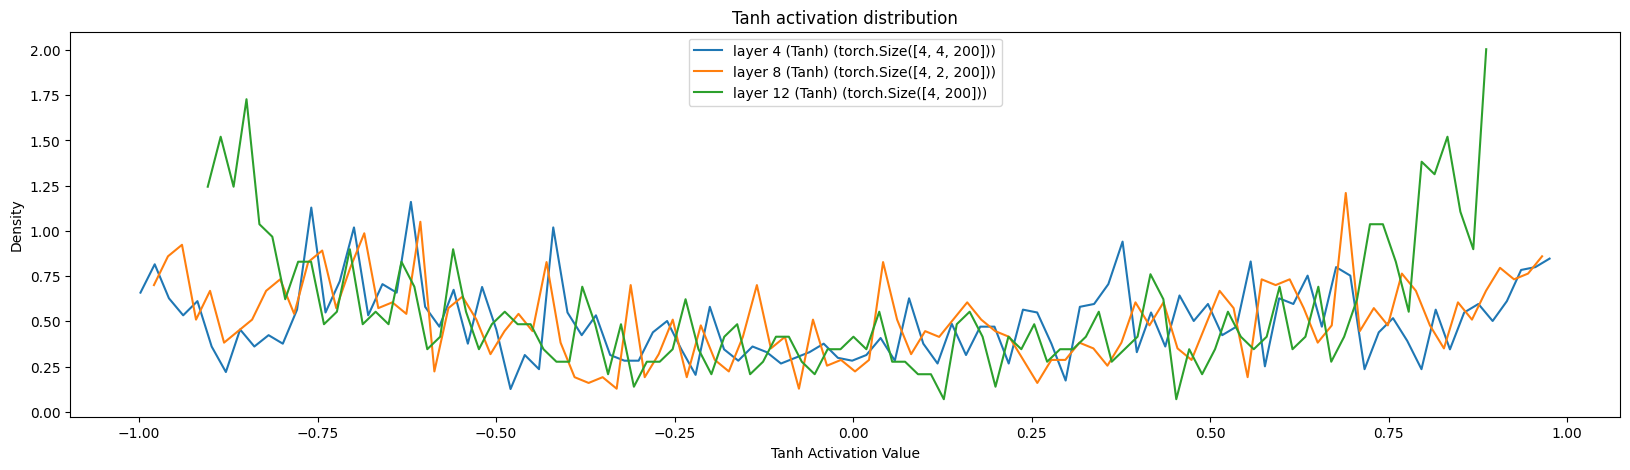


 ----------------------------------------------------------------------------------------------------
Tanh Grads distribution
Layer 4 (Tanh) grad_shape: torch.Size([4, 4, 200]) mean -0.0000 std: 0.0019
Layer 8 (Tanh) grad_shape: torch.Size([4, 2, 200]) mean 0.0000 std: 0.0018
Layer 12 (Tanh) grad_shape: torch.Size([4, 200]) mean -0.0000 std: 0.0017


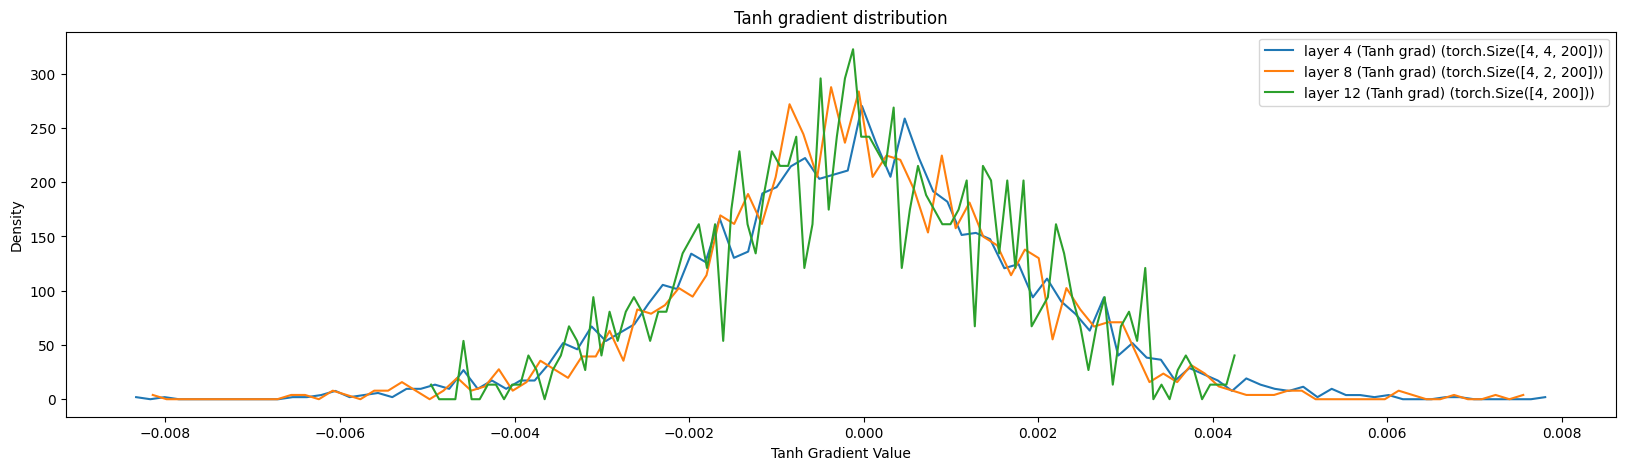


 ----------------------------------------------------------------------------------------------------
Weights grad distribution
Layer 0 weight shape: torch.Size([28, 64]) grad mean: 0.0000 gard std: 0.0016 grad/data ratio: 1.557782e-03
Layer 1 weight shape: torch.Size([128, 200]) grad mean: -0.0000 gard std: 0.0047 grad/data ratio: 5.266038e-02
Layer 4 weight shape: torch.Size([400, 200]) grad mean: -0.0000 gard std: 0.0040 grad/data ratio: 7.977053e-02
Layer 7 weight shape: torch.Size([400, 200]) grad mean: 0.0000 gard std: 0.0034 grad/data ratio: 6.813405e-02
Layer 10 weight shape: torch.Size([200, 28]) grad mean: 0.0000 gard std: 0.0508 grad/data ratio: 7.181536e+00


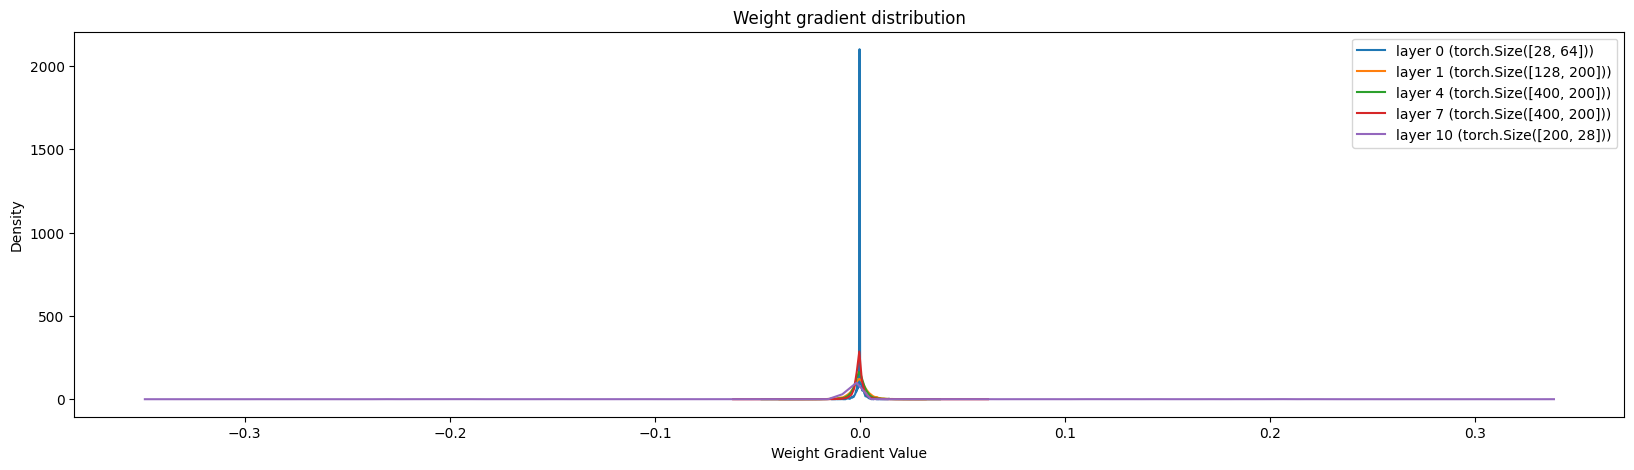


 ----------------------------------------------------------------------------------------------------
Parms Update to data ratio


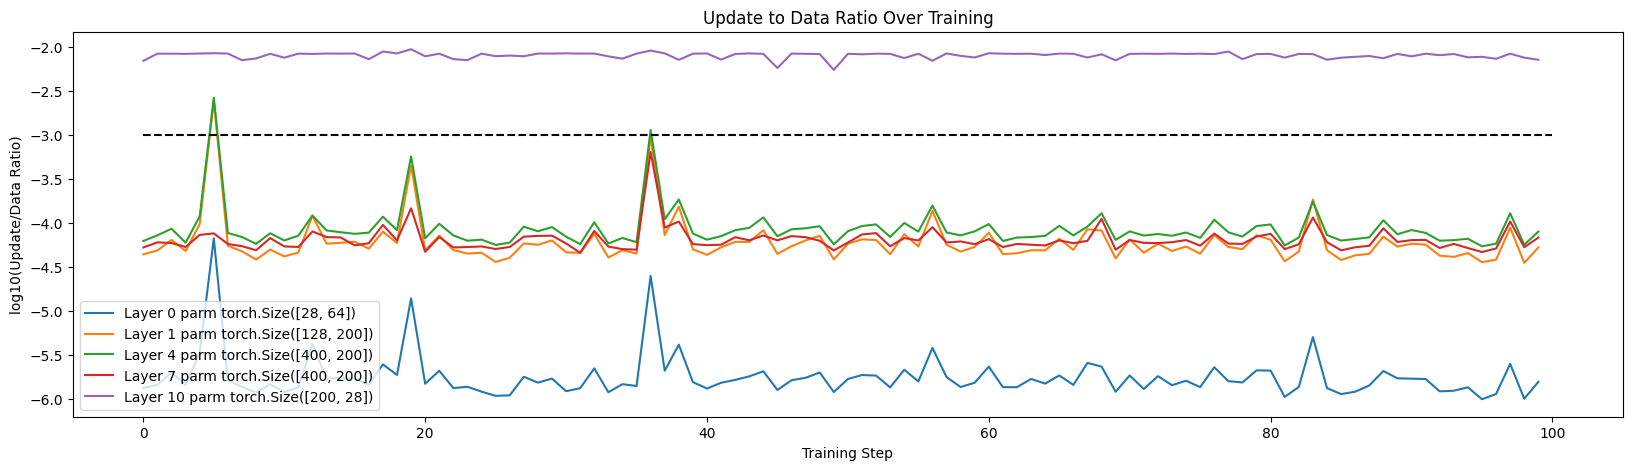


 ----------------------------------------------------------------------------------------------------
Loss across epochs


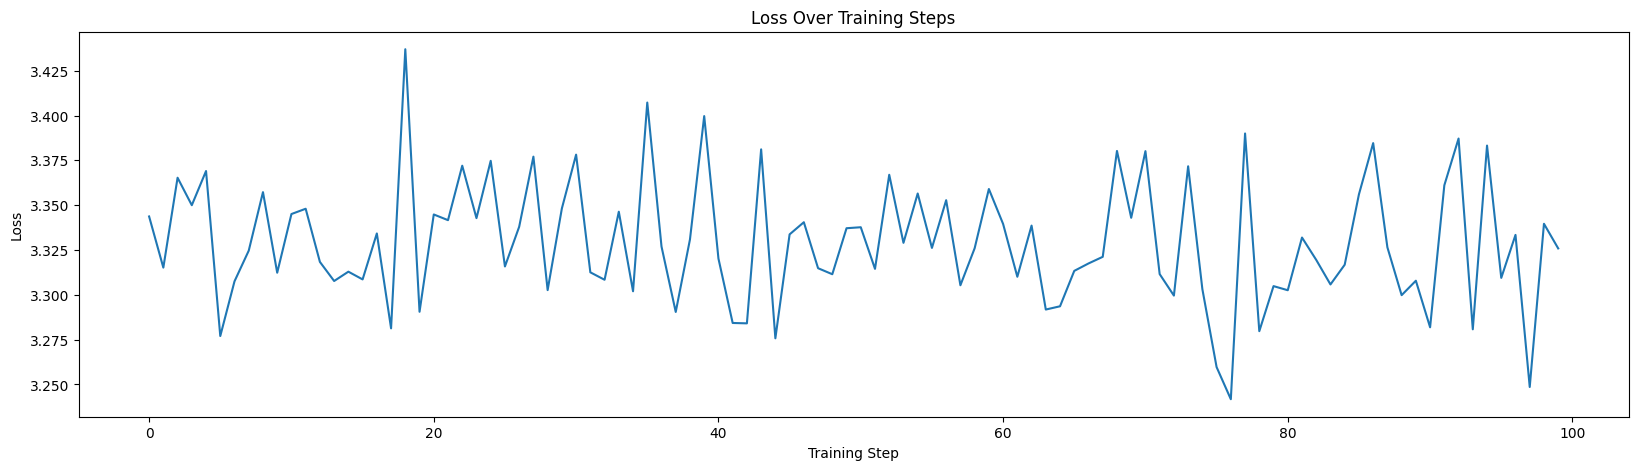


 ----------------------------------------------------------------------------------------------------


In [6]:
model.plot_diagnostic_graphs()

In [12]:
print("dev set loss:", model.loss_on_dev_set())
print("test set loss:", model.loss_on_test_set())

dev set loss: 1.9694132804870605
test set loss: 1.95375394821167


In [13]:
sample_words = model.sample_words(15, start_with='')
print(sample_words)
s = set(sample_words)
print(len(sample_words))

['bhanish', 'rohshiksuha', 'mopol', 'sushur', 'manel komarr', 'gurdlura s', 'daojan', 'sonjagy', 'vishal', 'argchansh', 'rema mik khm', 'sharksh', 'roj k hura', 'vihir tal', 'nharas chand']
15


In [ ]:
x = torch.randn((4, 8 , 10))
print(x.shape)
print(x[:, ::2 , :].shape)
print(x[:, 1::2 , :].shape)
c = torch.cat([x[:, ::2 , :], x[:, 1::2 , :]], dim=2)
print(c.shape)

# y = list(range(10))
# print(y[1::2])

torch.Size([4, 8, 10])
torch.Size([4, 4, 10])
torch.Size([4, 4, 10])
torch.Size([4, 4, 20])
